# Convolutional Neural Network: Colorectal Histology Image Classification

The goal of this project is to create a covolutional neural network capable of predicting the class of colon images. I would like to generate a model with a test accuracy > 90%.

The colorectal_histology data set available through TensforFlow came from the scientific report, “Multi-class texture analysis in colorectal cancer histology”. The data set contains 5000 images of colorectal cancer tissue biopsies under an Aperio ScanScope with 20x magnification. Each image is 150x150 pixels across the three (RGB) color channels. The images fall into 8 different classes representing 8 different histology types: ['tumor', 'stroma', 'complex', 'lympho', 'debris', 'mucosa', 'adipose', 'empty']. 

This model will be trained on a g4dn.xlarge Amazon Web Services EC2 instance which has one NVIDIA T4 Tensor Core GPU.

## Import Libraries and Set Random Seed

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt


import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

np.random.seed(42) # NEVER change this line

tf.keras.mixed_precision.set_global_policy('mixed_float16')



2025-11-10 16:38:18.363852: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 16:38:18.427345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 16:38:19.937365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Tensorflow and GPU connection sanity check

In [2]:
print("TensorFlow built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow built with CUDA: True
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Data

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

# Load the ColorectalHistology dataset
# The dataset typically comes with a 'train' split.
# We can use TFDS's slicing API to further split this 'train' split
# into custom train and test sets.
(train_ds, test_ds, val_ds), ds_info = tfds.load(
    'colorectal_histology',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:100%]' ],  # 80% for training, 20% for testing
    shuffle_files=True,  # Shuffle files before splitting
    as_supervised=True,  # Return (image, label) pairs
    with_info=True
)

# ds_info contains metadata about the dataset
print(f"Dataset info: {ds_info}")

I0000 00:00:1762792701.779520  537242 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Dataset info: tfds.core.DatasetInfo(
    name='colorectal_histology',
    full_name='colorectal_histology/2.0.0',
    description="""
    Classification of textures in colorectal cancer histology. Each example is a 150 x 150 x 3 RGB image of one of 8 classes.
    """,
    homepage='https://zenodo.org/record/53169#.XGZemKwzbmG',
    data_dir='/home/ubuntu/tensorflow_datasets/colorectal_histology/2.0.0',
    file_format=tfrecord,
    download_size=246.14 MiB,
    dataset_size=179.23 MiB,
    features=FeaturesDict({
        'filename': Text(shape=(), dtype=string),
        'image': Image(shape=(150, 150, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=8),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=5000, num_shards=2>,
    },
    citation="""@article{kather2016multi,
      title={Multi-class texture analysis in colorectal cancer histology},
      author={Kather, Jakob Ni

## Get Info on Loaded Data

In [4]:
# Show Train, Test, and Validate lengths
print(f'Number of Training Images:{len(train_ds)}')
print(f'Number of Validation Images:{len(val_ds)}')
print(f'Number of Testing Images:{len(test_ds)}')

print()

# Show Image Shape
for image, label in train_ds.take(1):
    print(f"Single Image Shape: {image.shape}, Single Label Shape: {label.shape}")

Number of Training Images:3500
Number of Validation Images:750
Number of Testing Images:750

Single Image Shape: (150, 150, 3), Single Label Shape: ()


2025-11-10 16:38:22.357751: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-11-10 16:38:22.367362: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Preprocess Data

In [5]:
# convert image data into tensors where each pixel value is a float that is normalized (between [0-1]) across all color channels
def preprocess_image(image, label): # augment=False):

    # convert image data into tensors where each pixel value is a float that is normalized (between [0-1]) across all color channels    
    image =tf.cast(image, tf.float32) / 255.0
    
    
    return image, label

def shuffle_and_batch(data_set, batch_size, buffer_size):
    
    # shuffle the data set, created batches of images, and set prefetch to AUTOTUNE for tf to optimize image data management 
    # during training (overlaps the preprocessing and model execution of a training step)
    data_set = data_set.shuffle(buffer_size=buffer_size) \
                    .batch(batch_size) \
                    .prefetch(AUTOTUNE)
    
    return data_set

In [6]:
# map current values in the tensor to normalized float32 values for both train and test datasets
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# Apply preprocessing without augmentation for test data
test_ds = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# Apply preprocessing without augmentation for validation data
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

# shuffle and batch training, validation, and test images
train_ds = shuffle_and_batch(data_set=train_ds, batch_size=32, buffer_size=1000)
val_ds = shuffle_and_batch(data_set=val_ds, batch_size=32, buffer_size=1000)
test_ds = shuffle_and_batch(data_set=test_ds, batch_size=32, buffer_size=1000)


In [7]:
# get the shape of our new traning data and make sure values in image tensors are between (0,1)
print("Train Data Set:")
for images, labels in train_ds.take(1):
    print(f'Images shape: {images.shape}, Labels shape: {labels.shape}')
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

print()

# get the shape of our new validation data and make sure values in image tensors are between (0,1)
print("Validation Data Set:")
for images, labels in val_ds.take(1):
    print(f'Images shape: {images.shape}, Labels shape: {labels.shape}')
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

print()

# get the shape of our new test data and make sure values in image tensors are between (0,1)
print("Test Data Set:")
for images, labels in test_ds.take(1):
    print(f'Images shape: {images.shape}, Labels shape: {labels.shape}')
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

print()

Train Data Set:
Images shape: (32, 150, 150, 3), Labels shape: (32,)
Min: 0.0
Max: 1.0

Validation Data Set:


2025-11-10 16:38:23.179208: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Images shape: (32, 150, 150, 3), Labels shape: (32,)
Min: 0.0
Max: 1.0

Test Data Set:
Images shape: (32, 150, 150, 3), Labels shape: (32,)
Min: 0.0
Max: 1.0



2025-11-10 16:38:24.026057: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Create Data Augmentation Function

Our data set is relatively small -- we have 5000 images, 3000 of which are used for model training. With a smaller data set, the CNN we create is at greater risk of overfitting than if we had a larger training data set. This is because the model is more likely to memorize training images rather than being good at generalizing to unseen data. Below we have a pipeline that can take in training images and apply flip, rotation and zooms randomly to the images. When this pipeline is called on the input training data when training the model, our model effectively sees many variations of the same images which acts like a regularization technique given that the model can't rely on pixel memorization from the original training data set.

In [8]:
# Use Keras Sequential model to define a data aumentation pipeline
augment_data_pipeline = keras.Sequential([    
    # --- Geometric adjustments ---
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
    ])

## Create Model Generator Function
Create a function to create our first 'basic' CNN model with stacked Conv2D and Maxpooling layers where the Conv2D layers increase in feature depth. This function as an optional parameter 'augment_data' -- this can be set to True, but is False by default.

In [9]:

def basic_cnn_generator(augment_data=False):

    inputs = keras.Input(shape=(150,150,3))

    x = inputs

    #call data augmentation pipeline on training data if augment_data is True
    if augment_data==True:
        x = augment_data_pipeline(x, training=True)

    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)


    x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

    x = layers.Flatten()(x)
    
    outputs = layers.Dense(8, activation="softmax", dtype='float32')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss='SparseCategoricalCrossentropy',
                optimizer='adam',
                metrics=['accuracy'])
    
    return model

### Create Early Stopping Callback
In order to speed up model training and avoid overfitting, I would like to create an early stopping callback to stop the model if validation accuracy fails to continue to improve after 5 epochs.

In [10]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

### Create a Basic CNN that does not use data augmentation, this will be our baseline model.

In [11]:
basic_model = basic_cnn_generator()

callbacks = make_callbacks()

history_1 = basic_model.fit(
    train_ds,
    epochs=40,
    callbacks=callbacks,
    validation_data = val_ds
)

Epoch 1/40


2025-11-10 16:38:27.134244: I external/local_xla/xla/service/service.cc:163] XLA service 0x5a2869549470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-10 16:38:27.134772: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-11-10 16:38:27.171439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-10 16:38:27.535388: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90501
2025-11-10 16:38:28.746007: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=4,k4=1,k5=3,k6=3,k7=2} for conv (f16[32,7,7,256]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,5,5,256]{3,2,1,0}, f16[256,3,3,256]{3,2,1,0}), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convB

 11/110 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1820 - loss: 2.0605

I0000 00:00:1762792714.465932  537282 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3348 - loss: 1.5589

2025-11-10 16:38:37.122856: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=4,k4=1,k5=3,k6=3,k7=2} for conv (f16[12,7,7,256]{3,2,1,0}, u8[0]{0}) custom-call(f16[12,5,5,256]{3,2,1,0}, f16[256,3,3,256]{3,2,1,0}), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-11-10 16:38:37.129539: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[12,7,7,256]{3,2,1,0}, u8[0]{0}) custom-call(f16[12,5,5,256]{3,2,1,0}, f16[256,3,3,256]{3,2,1,0}), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardI

110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.4406 - loss: 1.2667 - val_accuracy: 0.5560 - val_loss: 1.0346 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5860 - loss: 0.9623 - val_accuracy: 0.6787 - val_loss: 0.7566 - learning_rate: 0.0010
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6606 - loss: 0.8422 - val_accuracy: 0.7013 - val_loss: 0.6865 - learning_rate: 0.0010
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6946 - loss: 0.7506 - val_accuracy: 0.6347 - val_loss: 0.8941 - learning_rate: 0.0010
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7260 - loss: 0.6776 - val_accuracy: 0.7720 - val_loss: 0.6400 - learning_rate: 0.0010
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6814 - loss: 0.7603 - val_accuracy: 0.6733 - val_loss: 0.8005 - learning_rate: 0.0010
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7483 - loss: 0.6437 - val

In [12]:
def make_accuracy_loss_graphs(history):
    fig, axes = plt.subplots(1,2,figsize=(12,5))
    epochs = range(1, len(history.history['accuracy']) + 1)
    sns.lineplot(x=epochs, y=history.history['accuracy'], ax = axes[0], label="Train Accuracy")
    sns.lineplot(x=epochs, y=history.history['val_accuracy'], ax = axes[0], label="Val Accuracy")

    sns.lineplot(x=epochs, y=history.history['loss'], ax = axes[1], label="Training Loss")
    sns.lineplot(x=epochs, y=history.history['val_loss'], ax = axes[1], label="Val Loss")

    axes[0].set_title("Accuracy vs. Epoch")
    axes[1].set_title("Loss vs. Epoch")

    plt.legend()
    plt.show()

## Visualization of Model Performance

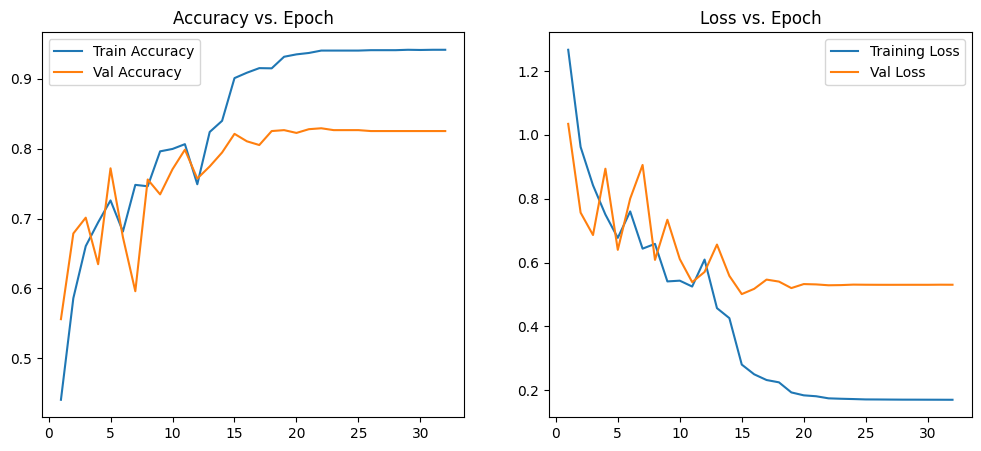

In [13]:
make_accuracy_loss_graphs(history_1)

## Test Accuracy

In [14]:
test_loss, test_acc = basic_model.evaluate(test_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8080 - loss: 0.5577


## Build Baseline Model Using Data Augmentation

In [15]:
basic_model_2 = basic_cnn_generator(augment_data=True)

callbacks = make_callbacks()

history_2 = basic_model_2.fit(
    train_ds,
    epochs=40,
    callbacks = [callbacks],
    validation_data = val_ds
)

Epoch 1/40


2025-11-10 16:39:59.837418: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3677 - loss: 1.3872 - val_accuracy: 0.5613 - val_loss: 1.1532 - learning_rate: 0.0010
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5320 - loss: 1.0363 - val_accuracy: 0.5133 - val_loss: 0.9745 - learning_rate: 0.0010
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6123 - loss: 0.8968 - val_accuracy: 0.6013 - val_loss: 1.0521 - learning_rate: 0.0010
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6651 - loss: 0.8325 - val_accuracy: 0.7293 - val_loss: 0.7264 - learning_rate: 0.0010
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7077 - loss: 0.7273 - val_accuracy: 0.7107 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6589 - loss: 0.8708 - val_accuracy: 0.6760 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7251 - loss: 0.6998 - val_

## Visualization of Model Perfomance

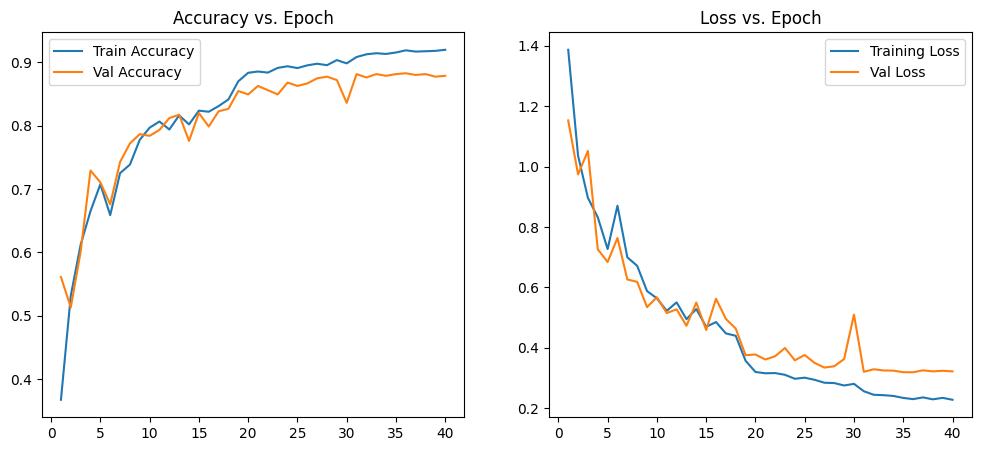

In [16]:
make_accuracy_loss_graphs(history_2)

## Test Accuracy

In [17]:
test_loss, test_acc = basic_model_2.evaluate(test_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8693 - loss: 0.3634


## Review of Above Models
From the training of the two models thus far, the baseline model without data augmentation and the baseline model with training data augmentation, we can see the positive impact of using data augmentation on the training data in this scenario. The model that was trained without data augmentation gave a test accuracy of 0.80, and with augmentation gave a test accuracy of 0.8693.

## Create Xception-Like Model
While the baseline model trained with data augmentation is a good starting point, we will now create a new model to compare to this model before choosing which model to perform hyperparameter tuning on. Below we create an Xception-like model inspired by the Xception-like model defined in Chapter 9.3.5, “Putting It Together: A Mini Xception-Like Model,” in Deep Learning with Python (2nd ed.) by François Chollet (2021). 

This model is designed to efficiently extract spatial feature information relying on residual connections and batch normalizations to eliminate noise and get a smooth gradient, but also seperableConv2D layers which are depth wise seperable convolutions.

In [18]:
def build_xception_model():

    inputs = keras.Input(shape=(150,150,3))

    inputs = augment_data_pipeline(inputs)
                           
    x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(inputs)

    # creating residual block for loop
    for size in [32, 64, 128, 256]:
        residual = x


        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False, depthwise_regularizer=keras.regularizers.l2(1e-4), pointwise_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.Dropout(0.25)(x)
    
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False, depthwise_regularizer=keras.regularizers.l2(1e-4), pointwise_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.Dropout(0.25)(x)


        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
  
        residual = layers.Conv2D(
            size, 1, strides=2, padding="same", use_bias=False)(residual)
        
        x = layers.add([x, residual])



    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(8, activation="softmax", dtype='float32')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss='SparseCategoricalCrossentropy',
                optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                metrics=['accuracy'])
    
    return model

In [19]:
xception_model = build_xception_model()

callbacks = make_callbacks()

history_3 = xception_model.fit(
    train_ds,
    epochs=50,
    callbacks=[callbacks],
    validation_data=val_ds
)

Epoch 1/50


2025-11-10 16:42:11.731843: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=3,k5=3,k6=3,k7=2} for conv (f16[32,146,146,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,150,150,4]{3,2,1,0}, f16[32,5,5,4]{3,2,1,0}), window={size=5x5}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-11-10 16:42:11.731888: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[32,146,146,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,150,150,4]{3,2,1,0}, f16[32,5,5,4]{3,2,1,0}), window={size=5x5}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", b

109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2594 - loss: 1.8823

2025-11-10 16:42:34.476424: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=0,k4=3,k5=3,k6=3,k7=2} for conv (f16[12,146,146,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[12,150,150,4]{3,2,1,0}, f16[32,5,5,4]{3,2,1,0}), window={size=5x5}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-11-10 16:42:34.476468: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[12,146,146,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[12,150,150,4]{3,2,1,0}, f16[32,5,5,4]{3,2,1,0}), window={size=5x5}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", b

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.2602 - loss: 1.8803

2025-11-10 16:42:51.062447: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=4,k4=1,k5=4,k6=3,k7=2} for conv (f16[32,73,73,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,73,73,32]{3,2,1,0}, f16[64,1,1,32]{3,2,1,0}), window={size=1x1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-11-10 16:42:51.082404: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k2=3,k4=2,k5=3,k6=3,k7=2} for conv (f16[32,73,73,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,73,73,32]{3,2,1,0}, f16[64,1,1,32]{3,2,1,0}), window={size=1x1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backe

110/110 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.3503 - loss: 1.6599 - val_accuracy: 0.1293 - val_loss: 2.2361 - learning_rate: 1.0000e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5423 - loss: 1.1729 - val_accuracy: 0.2507 - val_loss: 2.3606 - learning_rate: 1.0000e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6134 - loss: 1.0170 - val_accuracy: 0.2973 - val_loss: 2.1206 - learning_rate: 1.0000e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6523 - loss: 0.9183 - val_accuracy: 0.2693 - val_loss: 1.9047 - learning_rate: 1.0000e-04
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6931 - loss: 0.8358 - val_accuracy: 0.3360 - val_loss: 2.0906 - learning_rate: 1.0000e-04
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.7314 - loss: 0.7740 - val_accuracy: 0.3267 - val_loss: 2.3981 - learning_rate: 1.0000e-04
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.

## Visualize Training Performance

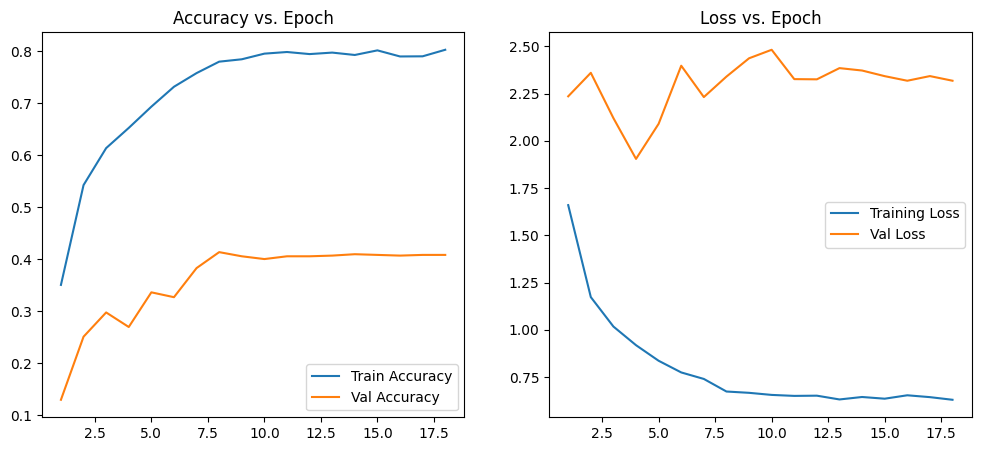

In [20]:
make_accuracy_loss_graphs(history_3)

## Test Accuracy

In [21]:
test_loss, test_acc = xception_model.evaluate(test_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4547 - loss: 2.2637


## Review of Xception-Like Model
As we can see above, the Xception-like model did not perform very well on validation data, and it was also possibly underfitting the training data. The test accuracy is much lower than the test accuracy from the previous two models.

## Hyperparameter Tuning
Given that the baseline model with data augmentation is the best performer so far based on its test accuracy, we are going to perform hyperparameter tuning using a construction similar to the baseline model with some added layers and parameters to be tuned during the tuner search process.

In [ ]:
def build_hp_tuned_model(hp):
    inputs = keras.Input(shape=(150, 150, 3))

    # Augmentation hyperparameters 
    use_flip = hp.Boolean("use_flip")
    rotation = hp.Float("rotation", min_value=0.0, max_value=0.2, step=0.05)
    zoom = hp.Float("zoom", min_value=0.0, max_value=0.3, step=0.05)

    augment_layers = []

    if use_flip:
        augment_layers.append(layers.RandomFlip("horizontal"))

    augment_layers.append(layers.RandomRotation(rotation))
    augment_layers.append(layers.RandomZoom(zoom))

    hp_augment_data_pipeline = keras.Sequential(augment_layers, name="data_augmentation")

    x = hp_augment_data_pipeline(inputs)

    # Tune base filter count
    filters_base = hp.Choice("filters_base", values=[32, 64])
    
    # Convolutional blocks
    for i, mult in enumerate([1, 2, 4, 8]):
        x = layers.Conv2D(filters=filters_base * mult, 
                          kernel_size=3,
                          activation="relu",
                          padding="same")(x)
        if hp.Boolean(f"use_batchnorm_{i}", default=True):
            x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=2)(x)
        
    # variable dropout layer
    x = layers.Dropout(hp.Float(f"dropout_rate_{i}", 0.0, 0.3, step=0.1))(x)

    x = layers.Flatten()(x)

    # Optional dense layer
    if hp.Boolean("use_dense_layer"):
        x = layers.Dense(hp.Int("dense_units", 128, 512, step=128),
                         activation="relu")(x)
        x = layers.Dropout(hp.Float("dense_dropout", 0.3, 0.6, step=0.1))(x)

    outputs = layers.Dense(8, activation="softmax", dtype='float32')(x)

    model = keras.Model(inputs, outputs)

    # Tune optimizer type and learning rate
    optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop"])
    lr = hp.Float("learning_rate", 1e-5, 1e-3, sampling="log")

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        loss="SparseCategoricalCrossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [23]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode = 'max',
        patience=5,
        min_delta=0.0,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )
]

In [24]:
tuner = kt.BayesianOptimization(
    build_hp_tuned_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=2,
    directory="ColonHistology_tuning",
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 12
use_flip (Boolean)
{'default': False, 'conditions': []}
rotation (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.2, 'step': 0.05, 'sampling': 'linear'}
zoom (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.3, 'step': 0.05, 'sampling': 'linear'}
filters_base (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
use_batchnorm_0 (Boolean)
{'default': True, 'conditions': []}
use_batchnorm_1 (Boolean)
{'default': True, 'conditions': []}
use_batchnorm_2 (Boolean)
{'default': True, 'conditions': []}
use_batchnorm_3 (Boolean)
{'default': True, 'conditions': []}
dropout_rate_3 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
use_dense_layer (Boolean)
{'default': False, 'conditions': []}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}
learning_r

In [25]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Trial 50 Complete [00h 09m 29s]
val_accuracy: 0.8913333415985107

Best val_accuracy So Far: 0.8980000019073486
Total elapsed time: 05h 15m 34s


## Hyperparameter Tuning Results

In [38]:
tuner.results_summary()

Results summary
Results in ColonHistology_tuning/untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
use_flip: False
rotation: 0.15000000000000002
zoom: 0.05
filters_base: 64
use_batchnorm_0: True
use_batchnorm_1: False
use_batchnorm_2: True
use_batchnorm_3: False
dropout_rate_3: 0.2
use_dense_layer: True
optimizer: rmsprop
learning_rate: 0.0002645779114887671
dense_units: 128
dense_dropout: 0.5
Score: 0.8980000019073486

Trial 35 summary
Hyperparameters:
use_flip: False
rotation: 0.15000000000000002
zoom: 0.1
filters_base: 64
use_batchnorm_0: True
use_batchnorm_1: False
use_batchnorm_2: True
use_batchnorm_3: False
dropout_rate_3: 0.1
use_dense_layer: False
optimizer: rmsprop
learning_rate: 0.0002215869281239299
dense_units: 256
dense_dropout: 0.5
Score: 0.8980000019073486

Trial 06 summary
Hyperparameters:
use_flip: True
rotation: 0.15000000000000002
zoom: 0.15000000000000002
filters_base: 32
use_batchnorm_0: True


## Get Best Model From Hyperparameter Tuning

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

In [54]:
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,861,832 (26.18 MB)

 Trainable params: 6,861,192 (26.17 MB)

 Non-trainable params: 640 (2.50 KB)

## Test Accuracy of Best Model

In [55]:
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Best test accuracy: {test_acc:.3f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9173 - loss: 0.2666
Best test accuracy: 0.917


## Discussion
As we can see, the hyperparameter tuning did exactly what we wanted. We now have a model that has 0.9173 test accuracy which is much better than our previous best test-accuracy prior to hyperparamter tuning (~0.86). 

### Make Predictions and Show Results
Below we will make predictions with the new best model we extracted from our hyperparameter tuning above and print the images we predicted on as well as the true and predicted labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


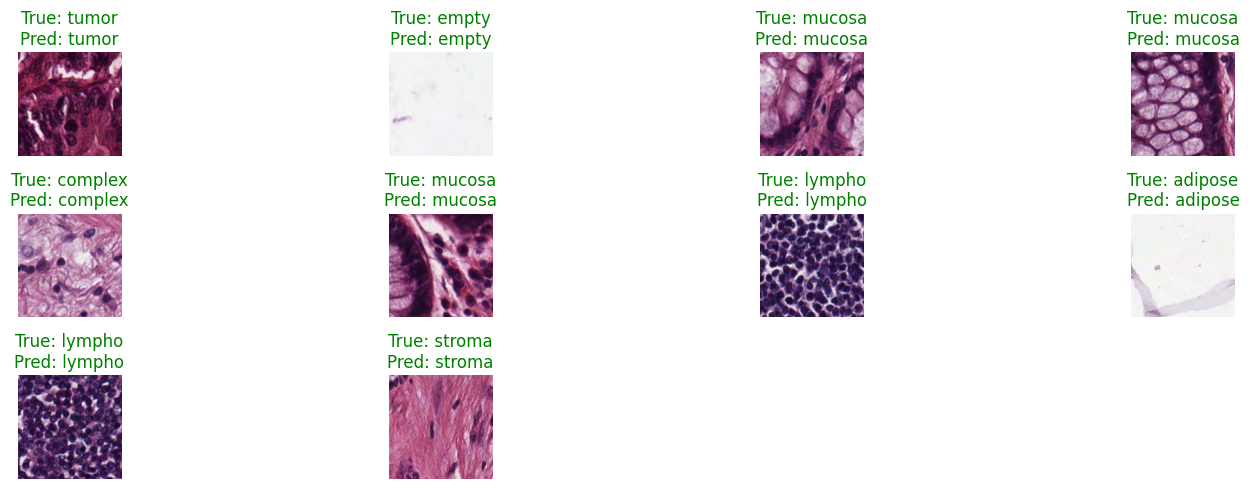

In [ ]:
class_names = ds_info.features['label'].names

test_ds_unbatched = test_ds.unbatch().batch(10)  # batch 10 for plotting
for images, labels in test_ds_unbatched.take(1):
    images = images.numpy()
    labels = labels.numpy()
    preds_batch = best_model.predict(images)
    pred_labels = preds_batch.argmax(axis=1)

plt.figure(figsize=(15, 5))
batch_size = images.shape[0]

for i in range(min(batch_size, 10)):  # plot up to 12 images
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    true_label = class_names[labels[i]]
    pred_label = class_names[pred_labels[i]]
    color = 'green' if labels[i] == pred_labels[i] else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
plt.tight_layout()
plt.show()

## Discussion
We completed our objective of generating an image classifier with a test accuracy > 90%. We can see the power of constructing a baseline model, using data augmentation, and the importance of performing hyperparameter tuning with the introduction of additional normalization and regularization layers.